#  New York City Datenbereinigung, erste einfache EDA und Regression

Datensatz von https://insideairbnb.com/get-the-data/

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

In [3]:
df = pd.read_csv("listings_NYC.csv")

In [4]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40824219,https://www.airbnb.com/rooms/40824219,20251001171547,2025-10-02,city scrape,Room close to Manhattan for FEMALE guests,This cozy spacious room includes a twin size b...,Sunnyside is a safe residental area. <br />The...,https://a0.muscache.com/pictures/hosting/Hosti...,317540555,...,4.88,4.94,4.69,NaN,f,3,0,3,0,0.23
1,40833186,https://www.airbnb.com/rooms/40833186,20251001171547,2025-10-02,previous scrape,Soho LES East village private room downtown,NaN,NaN,https://a0.muscache.com/pictures/1f093bbc-936c...,68718914,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
2,40837137,https://www.airbnb.com/rooms/40837137,20251001171547,2025-10-02,previous scrape,Sunset Park - Quiet and close to subway!,"Cozy, lovely bedroom with a comfortable full s...",the sunset park of Brooklyn,https://a0.muscache.com/pictures/01c4e91e-4012...,317770098,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
3,40838018,https://www.airbnb.com/rooms/40838018,20251001171547,2025-10-02,previous scrape,Cozy One Bedroom in Clinton Hill,This sunny one-bedroom apartment is located in...,Clinton Hill is one of the best neighborhoods ...,https://a0.muscache.com/pictures/9322d54a-6eb7...,17211451,...,5.00,5.00,5.00,NaN,t,1,1,0,0,0.01
4,40839416,https://www.airbnb.com/rooms/40839416,20251001171547,2025-10-02,city scrape,🪴XL dojo 🌾 shared green yogi palace apt 🌿,"New York City living at its best. A massive, c...",Live like the Ramones > The East Village is st...,https://a0.muscache.com/pictures/hosting/Hosti...,4765305,...,5.00,5.00,4.95,NaN,f,8,0,8,0,0.40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36111 non-null  int64  
 1   listing_url                                   36111 non-null  object 
 2   scrape_id                                     36111 non-null  int64  
 3   last_scraped                                  36111 non-null  object 
 4   source                                        36111 non-null  object 
 5   name                                          36109 non-null  object 
 6   description                                   35153 non-null  object 
 7   neighborhood_overview                         18704 non-null  object 
 8   picture_url                                   36111 non-null  object 
 9   host_id                                       36111 non-null 

## Feature Engineering: Distance to center als neue Spalte

Ausgangspunkt: latitude, longitude   
Ziel: Abstand zum Timessquare (als Center von NYC messen)

In [6]:
pip install ipynbname

Note: you may need to restart the kernel to use updated packages.


In [7]:
import 

SyntaxError: invalid syntax (2494350585.py, line 1)

In [ ]:
from src.data_cleaning import calculate_distance, CENTER_LAT, CENTER_LON 

df['distance_to_center'] = calculate_distance(
    df['latitude'], 
    df['longitude'], 
    CENTER_LAT, 
    CENTER_LON
)

# 2. ALLE NÖTIGEN SPALTEN AUSWÄHLEN und KOPIEREN
SPALTEN_FUER_MODELL = [
    'accommodates', 
    'host_total_listings_count', 
    'review_scores_rating', 
    'price',
    'availability_365',
    
    'distance_to_center' # NEUE SPALTE HINZUGEFÜGT
]
df_clean = df[SPALTEN_FUER_MODELL].copy()

In [44]:
SPALTEN_REDUZIERT = [
    'accommodates',
    'price',
    'host_total_listings_count',
    'review_scores_rating', 
    'latitude', 
    'longitude', 
    'availability_365'
] 

In [45]:
df_simple = df[SPALTEN_REDUZIERT].copy()

In [46]:
df_simple.head()

,accommodates,price,host_total_listings_count,review_scores_rating,latitude,longitude,availability_365
0,1,$66.00,3.0,4.81,40.74698,-73.91763,77
1,2,NaN,1.0,NaN,40.72314,-73.99323,0
2,1,NaN,1.0,5.00,40.64607,-74.00552,0
3,1,NaN,3.0,5.00,40.68370,-73.96115,0
4,1,$76.00,16.0,4.95,40.72147,-73.98270,168


In [47]:
df_clean = df_simple.dropna(subset=['price']).copy()
print(f"Zeilen nach der Preislöschung: {len(df_clean)}")

Zeilen nach der Preislöschung: 21328


In [48]:
# 1. Entfernen von Währungszeichen ($), Kommas (,) und Leerzeichen
df_clean['price'] = df_clean['price'].astype(str).str.replace(r'[$,\s]', '', regex=True)

# 2. Konvertieren zu numerischem Float
# Wichtig: errors='coerce' verwandelt Einträge, die nicht konvertiert werden können (z.B. leere Zellen, 'N/A'), in NaN.
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

In [49]:
df_clean['accommodates'] = df_clean['accommodates'].astype(float)

### Imputation fehlender Werte

In [50]:
IMPUTATIONS_SPALTEN = ['host_total_listings_count', 'review_scores_rating']

for col in IMPUTATIONS_SPALTEN:
    median_wert = df_clean[col].median()
    
    # KORRIGIERT: Keine inplace=True. Das Ergebnis der fillna-Operation 
    # wird direkt der Spalte zugewiesen.
    df_clean[col] = df_clean[col].fillna(median_wert)
    
    print(f"  -> Spalte '{col}': NaNs durch Median ({median_wert:.2f}) ersetzt.")

  -> Spalte 'host_total_listings_count': NaNs durch Median (5.00) ersetzt.
  -> Spalte 'review_scores_rating': NaNs durch Median (4.86) ersetzt.


In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21328 entries, 0 to 36110
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               21328 non-null  float64
 1   price                      21328 non-null  float64
 2   host_total_listings_count  21328 non-null  float64
 3   review_scores_rating       21328 non-null  float64
 4   latitude                   21328 non-null  float64
 5   longitude                  21328 non-null  float64
 6   availability_365           21328 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 1.3 MB


Lückenloser Datensatz liegt vor! 

In [52]:
df_clean.to_csv('listings_short_NYC.csv')

In [53]:
df1=df_clean

### EDA

siehe: https://www.youtube.com/watch?v=O2Cw82YR5Bo

In [54]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21328 entries, 0 to 36110
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               21328 non-null  float64
 1   price                      21328 non-null  float64
 2   host_total_listings_count  21328 non-null  float64
 3   review_scores_rating       21328 non-null  float64
 4   latitude                   21328 non-null  float64
 5   longitude                  21328 non-null  float64
 6   availability_365           21328 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 1.3 MB


In [55]:
df1.describe()

,accommodates,price,host_total_listings_count,review_scores_rating,latitude,longitude,availability_365
count,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000
mean,2.868014,680.526819,244.445940,4.769270,40.727018,-73.944055,251.044120
std,2.021471,4480.453282,1015.854308,0.381238,0.058734,0.060404,106.941151
min,1.000000,10.000000,1.000000,1.000000,40.500366,-74.251907,0.000000
25%,2.000000,89.000000,2.000000,4.760000,40.685195,-73.983262,172.000000
50%,2.000000,154.000000,5.000000,4.860000,40.726895,-73.953500,276.000000
75%,4.000000,279.000000,22.000000,4.930000,40.763037,-73.922741,347.000000
max,16.000000,50104.000000,9764.000000,5.000000,40.912017,-73.711822,365.000000


#### Zielvariable Price

a) Boxplots

<Axes: xlabel='price'>

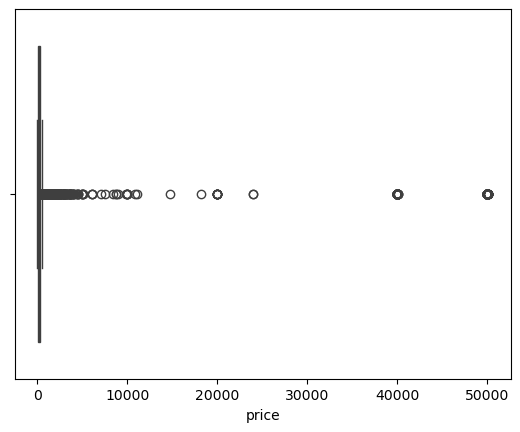

In [56]:
sns.boxplot(x='price', data= df1)

Wenn Sie sich nicht auf einen festen Wert ($1000) festlegen möchten, können Sie auch das 99. Perzentil Ihres eigenen Datensatzes verwenden. Das schließt die extremsten 1% der Ausreißer aus und zeigt 99% der Daten:

99. Perzentil liegt bei: $19514.00


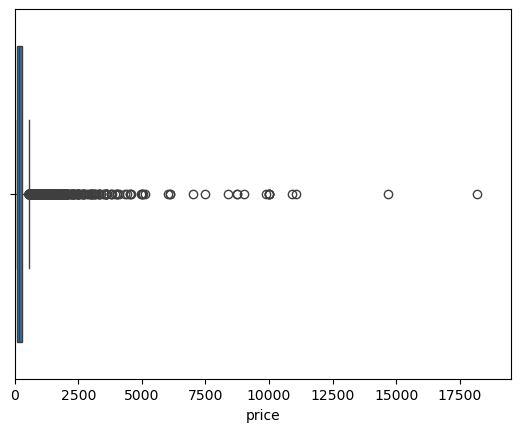

In [57]:
# Berechnung des 99. Perzentils
limit_99 = df1['price'].quantile(0.99)
print(f"99. Perzentil liegt bei: ${limit_99:.2f}") 

# Plot-Befehl mit dem berechneten Limit:
sns.boxplot(x='price', data=df1)
plt.xlim(0, limit_99) 
plt.show()

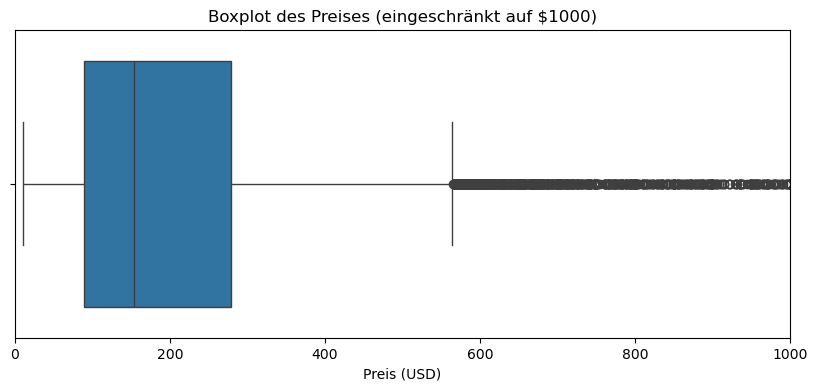

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Wir verwenden df_clean, den bereinigten Datensatz
# mit der numerischen 'price' Spalte

plt.figure(figsize=(10, 4))

# 1. Erstellen des Boxplots
sns.boxplot(x='price', data=df_clean)

# 2. EINSCHRÄNKUNG DER X-ACHSE (von 0 bis 1000 USD)
# Dies skaliert das Diagramm neu, um nur diesen Bereich anzuzeigen.
# Wenn Sie den Plot in der Zelle ausführen, wird er so angezeigt.
plt.xlim(0, 1000) 

plt.title('Boxplot des Preises (eingeschränkt auf $1000)')
plt.xlabel('Preis (USD)')
plt.show()

#### Scatterplots

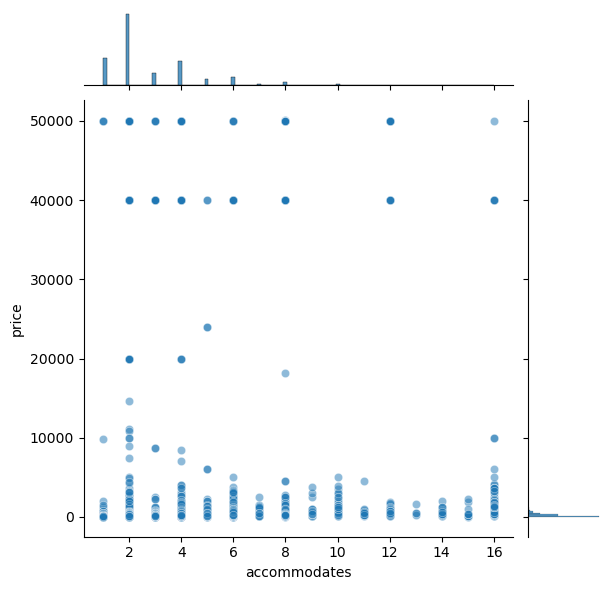

In [59]:
sns.jointplot(x='accommodates', y='price', data=df1, alpha=0.5)

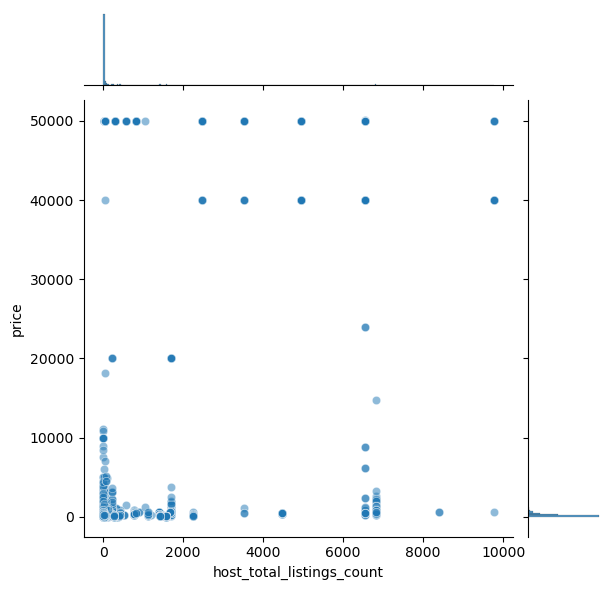

In [60]:
sns.jointplot(x='host_total_listings_count', y='price', data=df1, alpha=0.5)

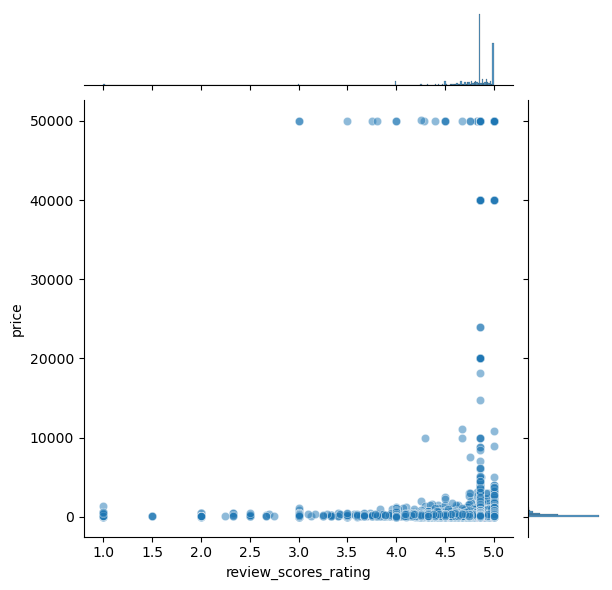

In [61]:

sns.jointplot(x='review_scores_rating', y='price', data=df1, alpha=0.5)

### Zielvariable Price - mit ln-transformation

Erstellen der neuen Spalte 'ln_price':

In [62]:
import numpy as np


df1['ln_price'] = np.log1p(df1['price'])

print("✅ Spalte 'ln_price' erfolgreich erstellt.")
print(df1[['price', 'ln_price']].head())

✅ Spalte 'ln_price' erfolgreich erstellt.
   price  ln_price
0   66.0  4.204693
4   76.0  4.343805
5   97.0  4.584967
7   60.0  4.110874
8  425.0  6.054439


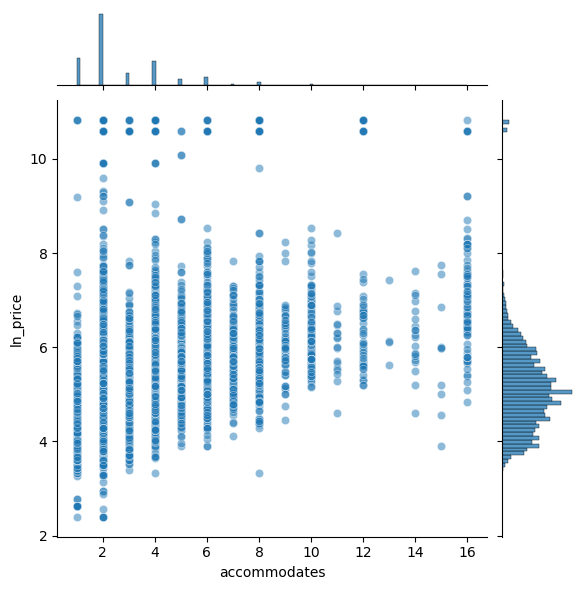

In [63]:
sns.jointplot(x='accommodates', y='ln_price', data=df1, alpha=0.5)

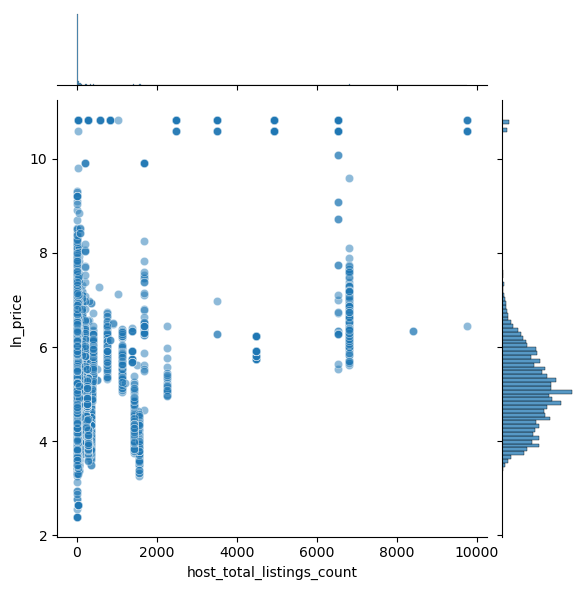

In [64]:
sns.jointplot(x='host_total_listings_count', y='ln_price', data=df1, alpha=0.5)

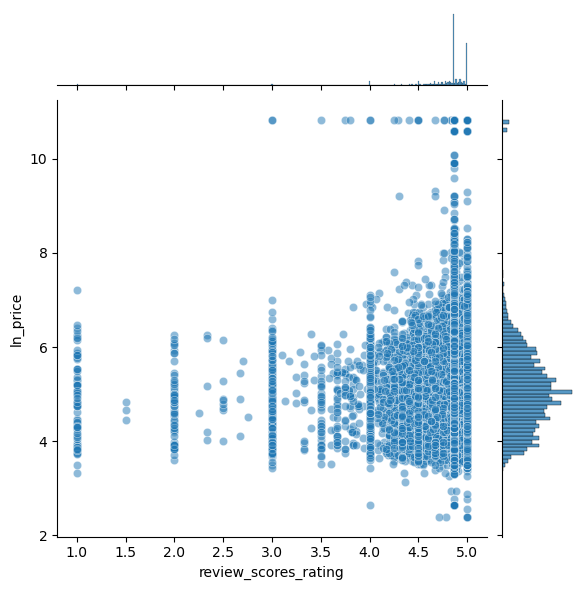

In [65]:
sns.jointplot(x='review_scores_rating', y='ln_price', data=df1, alpha=0.5)

### Gemeinsame Visualisierung von 'price' und 'ln_price'

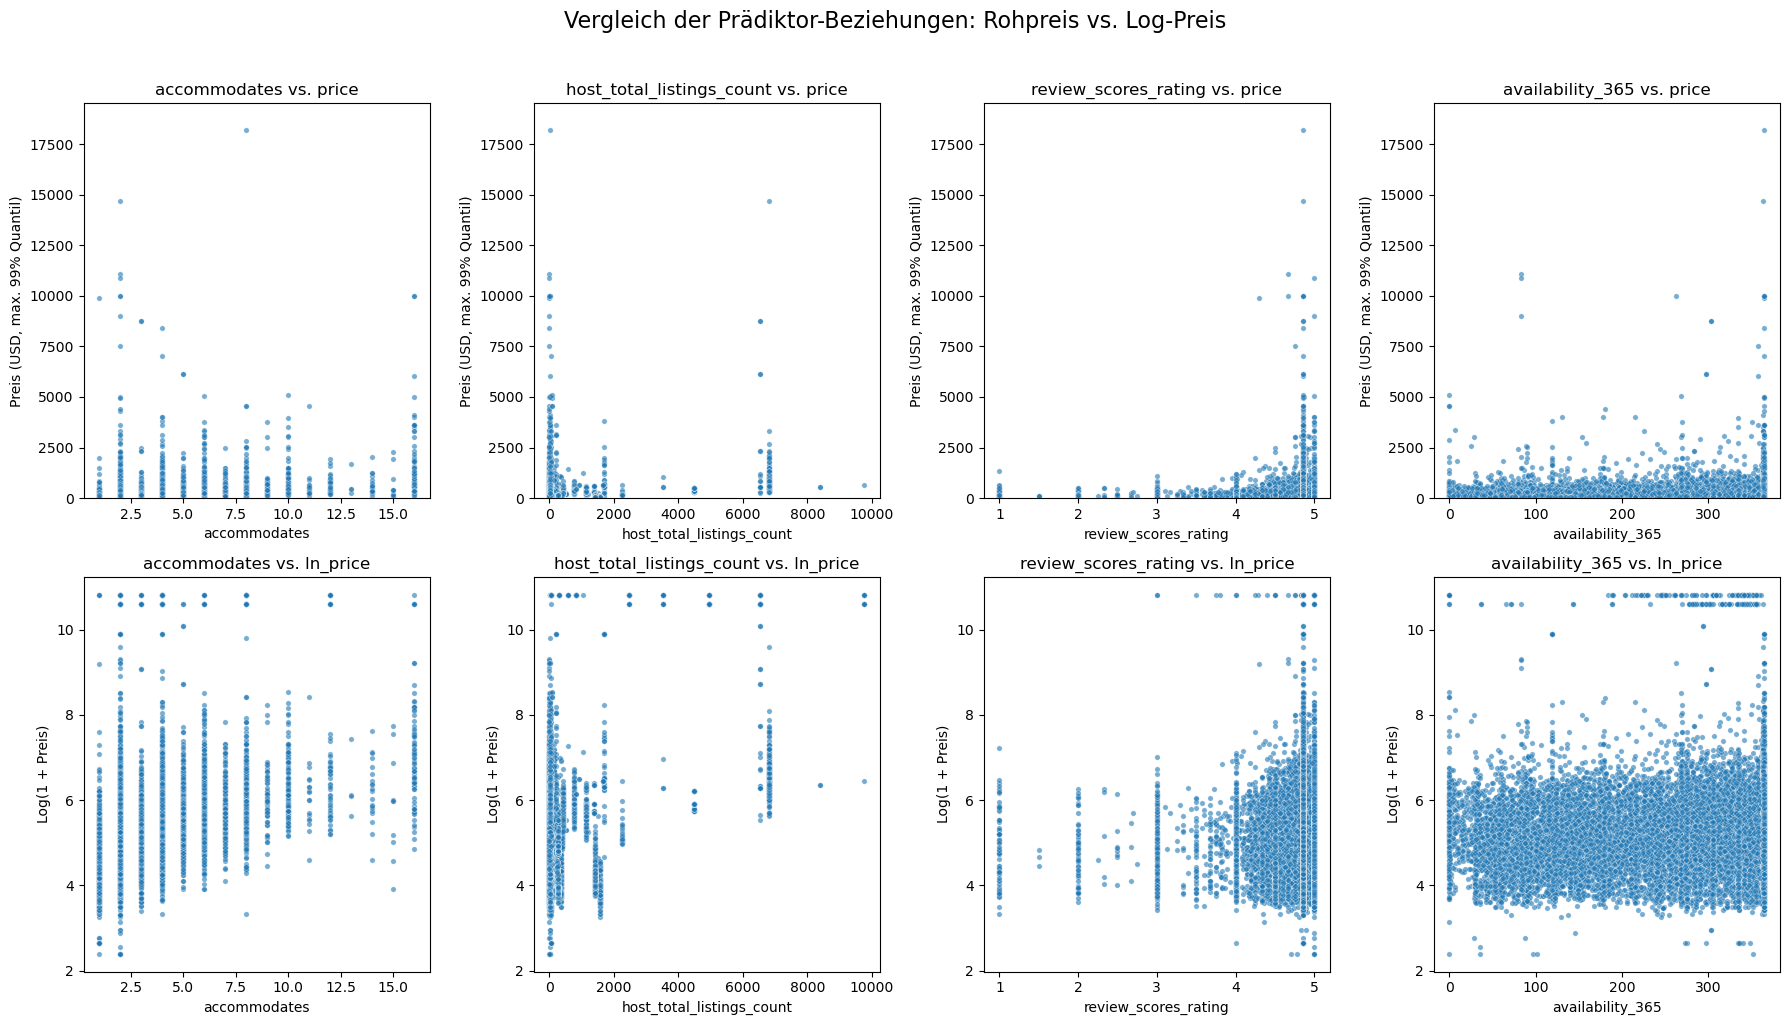

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Nur zur Sicherheit, falls nicht importiert

# Annahme: df_clean enthält die Spalten 'price' und 'ln_price'
PREDICTOR_SPALTEN = ['accommodates', 'host_total_listings_count', 'review_scores_rating', 'availability_365']
TARGET_SPALTEN = ['price', 'ln_price']

# Definition des maximalen Werts für die y-Achse des rohen Preises (zur besseren Sichtbarkeit)
PRICE_LIMIT = df_clean['price'].quantile(0.99)

# Erstellen der großen Figur: 2 Reihen, 3 Spalten (2x3 Grid)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
plt.suptitle('Vergleich der Prädiktor-Beziehungen: Rohpreis vs. Log-Preis', fontsize=16, y=1.02)

# Abflachen des Achsen-Arrays, um es leicht durchlaufen zu können
# axes[0, 0], axes[0, 1], axes[0, 2] = Erste Reihe (price)
# axes[1, 0], axes[1, 1], axes[1, 2] = Zweite Reihe (ln_price)

# Äußere Schleife: Durchläuft die Zielvariablen (Reihen)
for row_index, target in enumerate(TARGET_SPALTEN):
    
    # Innere Schleife: Durchläuft die Prädiktoren (Spalten)
    for col_index, predictor in enumerate(PREDICTOR_SPALTEN):
        
        # Zugriff auf die korrekte Subplot-Position (axes[Reihe, Spalte])
        ax = axes[row_index, col_index]
        
        # Erstellen des Scatterplots
        sns.scatterplot(
            x=df_clean[predictor], 
            y=df_clean[target], 
            ax=ax, 
            alpha=0.6, 
            s=15 # Größe der Punkte
        )
        
        ax.set_title(f'{predictor} vs. {target}')
        ax.set_xlabel(predictor)
        
        # Nur für die obere Reihe (price): Y-Achse auf PRICE_LIMIT begrenzen
        if target == 'price':
            ax.set_ylim(0, PRICE_LIMIT)
            ax.set_ylabel('Preis (USD, max. 99% Quantil)')
        else:
            ax.set_ylabel('Log(1 + Preis)')
            
# Sicherstellen, dass die Plots sich nicht überlappen
plt.tight_layout()
plt.show()

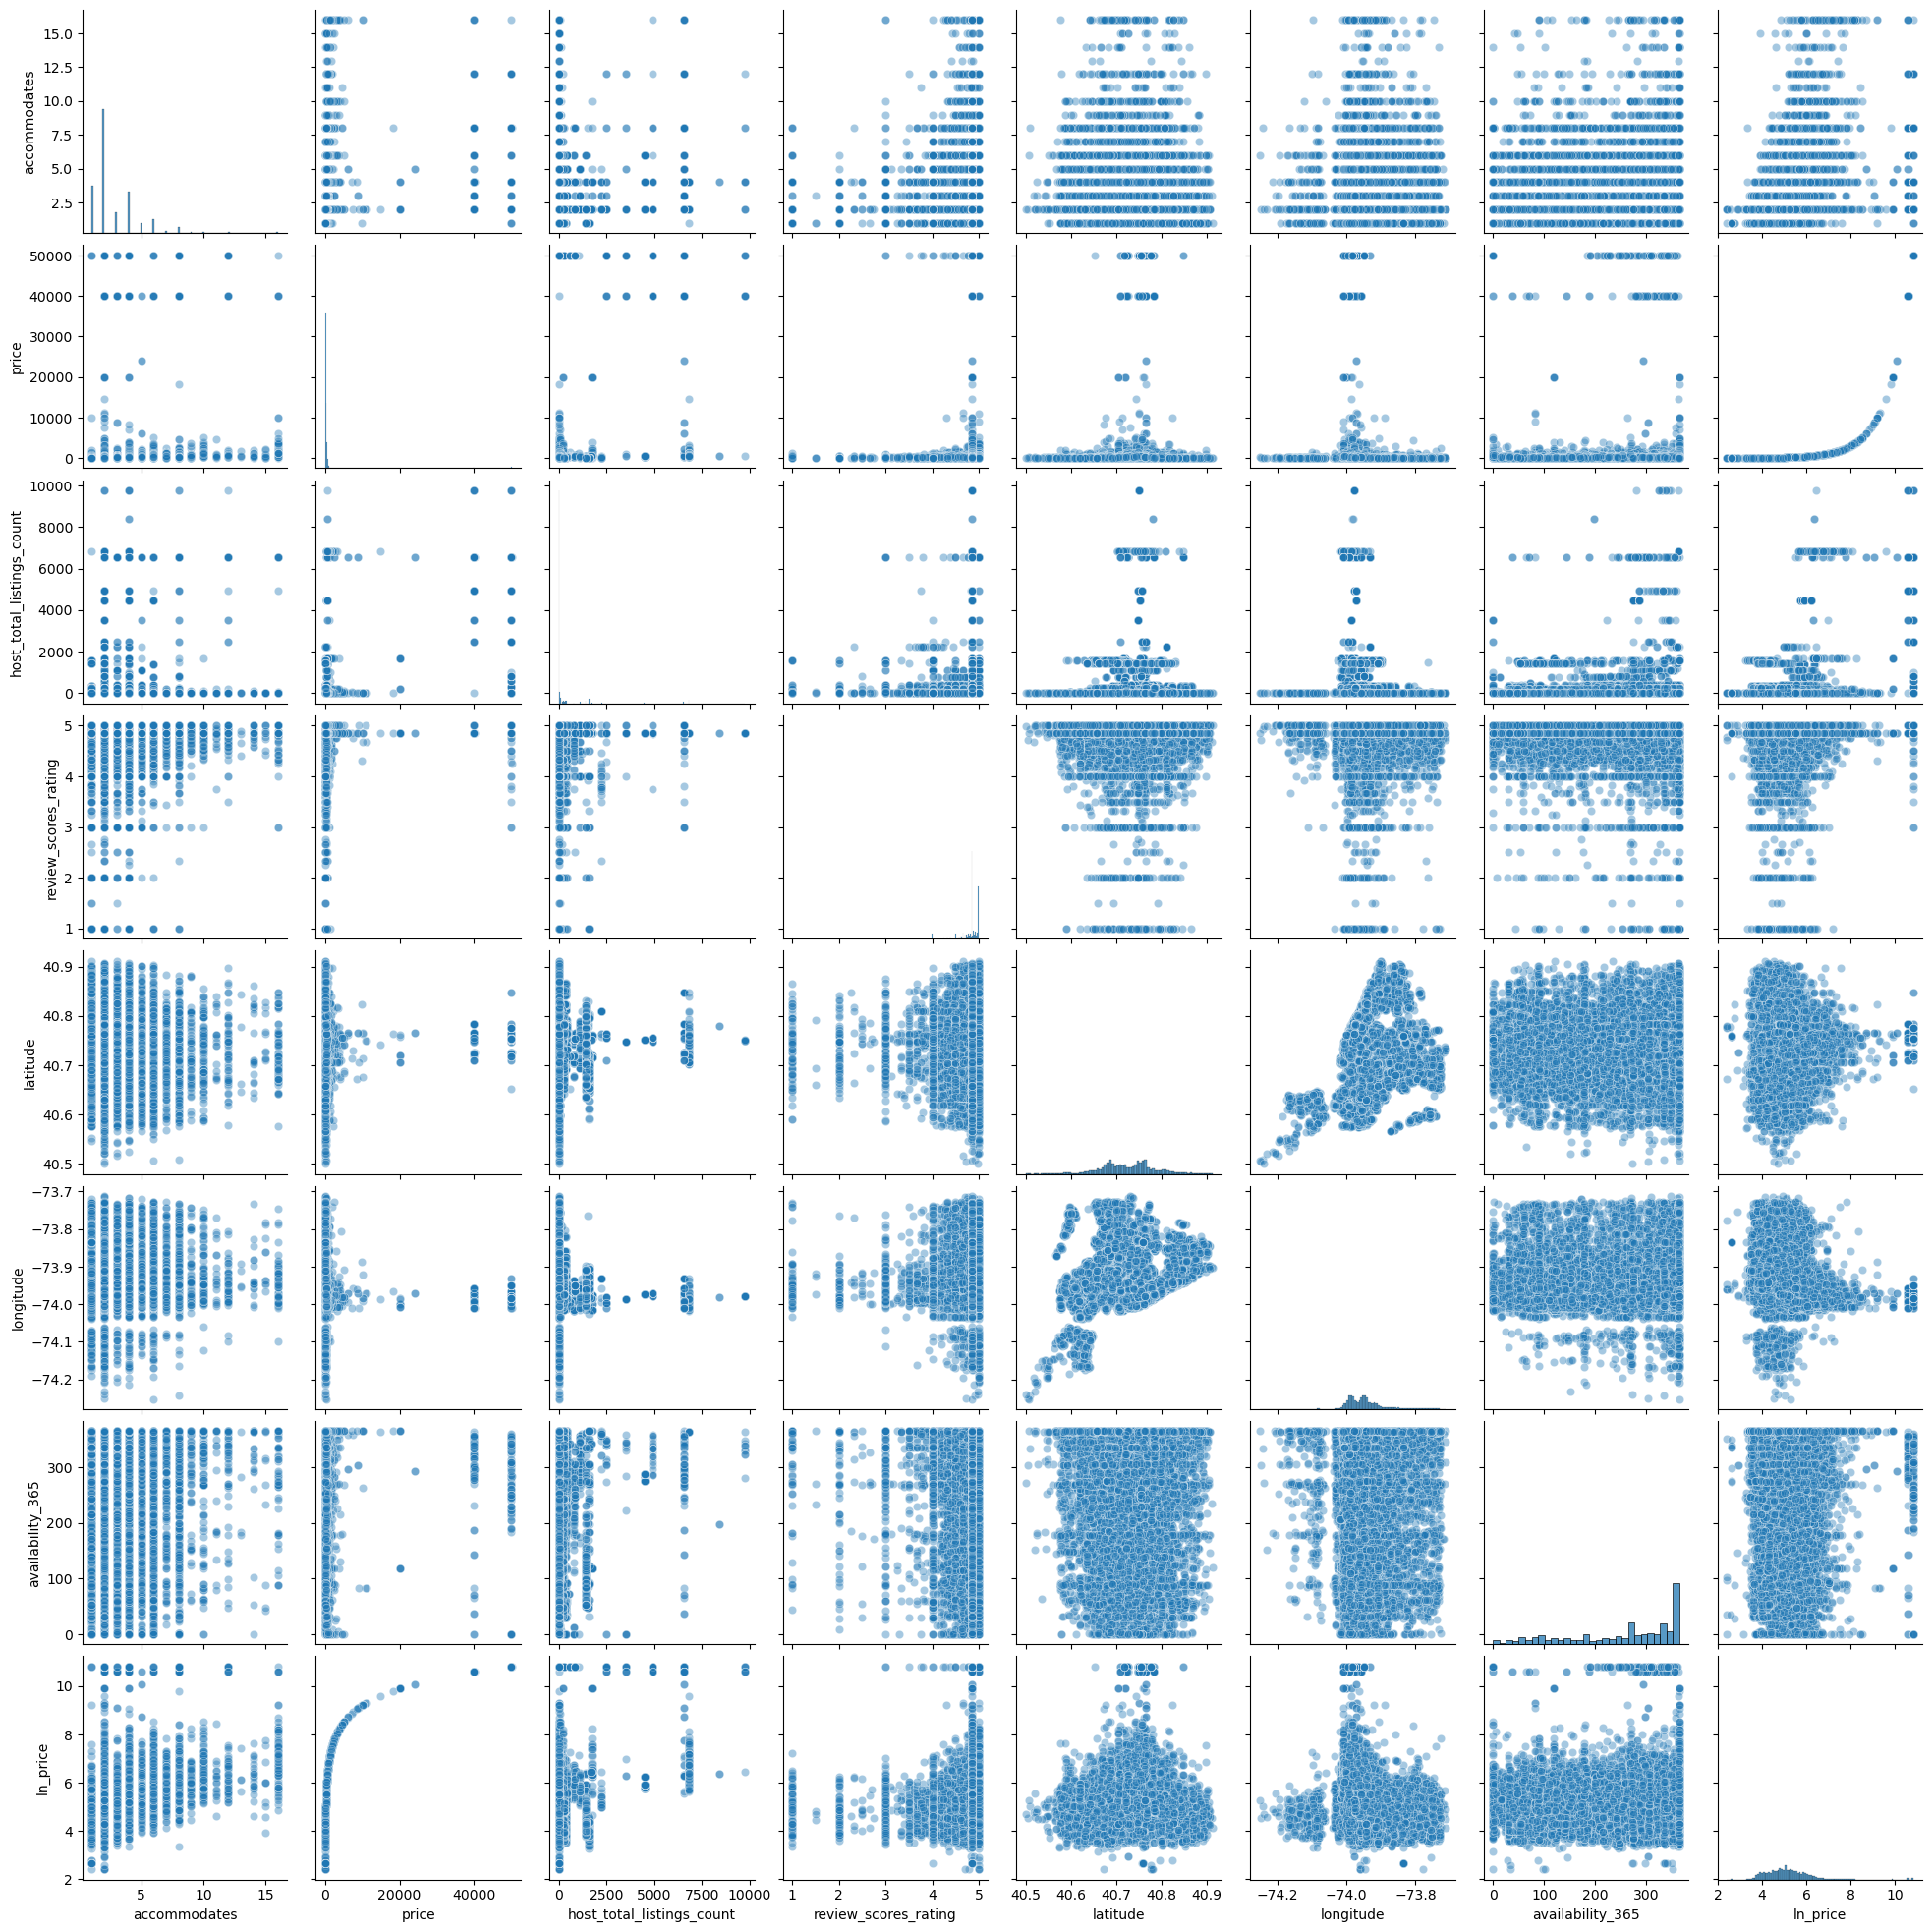

In [73]:
sns.pairplot(df1, kind='scatter', plot_kws={'alpha':0.4})

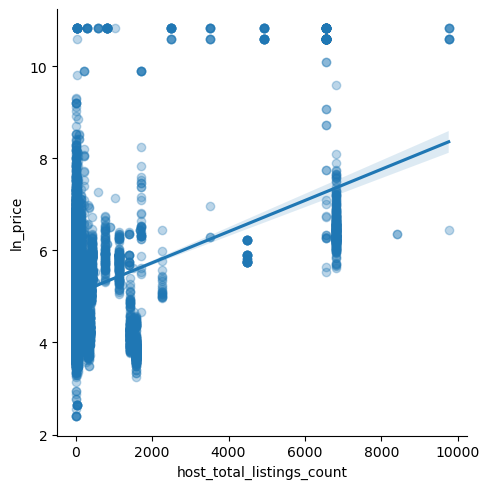

In [74]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

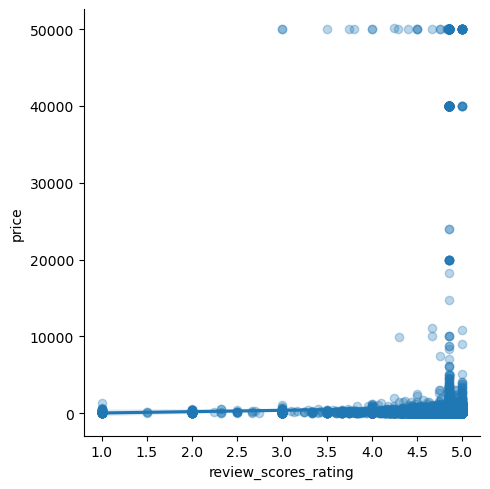

In [75]:
sns.lmplot(x = 'review_scores_rating', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

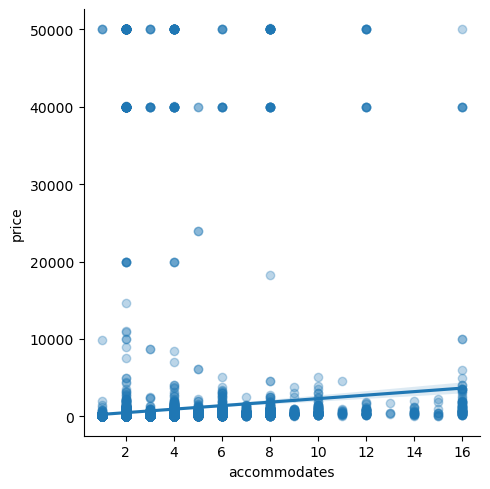

In [76]:
sns.lmplot(x = 'accommodates', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

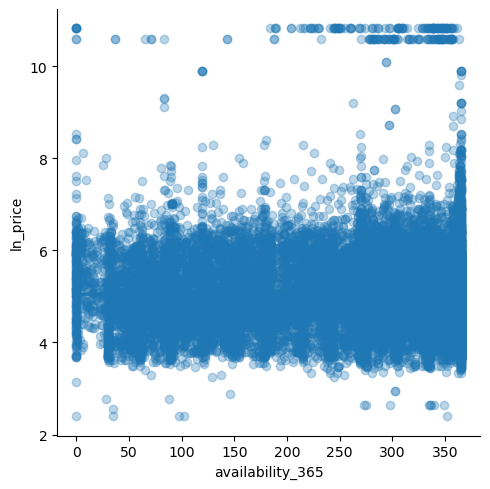

In [78]:
sns.lmplot(x = 'availability_365', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

In [80]:
from sklearn.model_selection import train_test_split

In [83]:
X = df1[['host_total_listings_count', 'accommodates', 'availability_365']]
y = df1['ln_price']

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [89]:
y_train

12857    4.727388
20012    5.683580
22927    5.062595
1178     5.129899
30404    6.723832
           ...   
24089    5.908083
24937    4.394449
15398    4.304065
1770     5.429346
29669    4.653960
Name: ln_price, Length: 14929, dtype: float64

# Training the model

In [90]:
from sklearn.linear_model import LinearRegression

In [91]:
lm = LinearRegression()

In [93]:
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Koeffizienten

In [94]:
lm.coef_

array([ 0.00035456,  0.22312424, -0.00027287])

In [98]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
print(cdf)

                               Coef
host_total_listings_count  0.000355
accommodates               0.223124
availability_365          -0.000273


### Predictions

In [99]:
predictions = lm.predict(X_test)

In [100]:
predictions

array([5.07554243, 4.90765313, 5.07226796, ..., 4.88145737, 4.96642168,
       7.16434815], shape=(6399,))

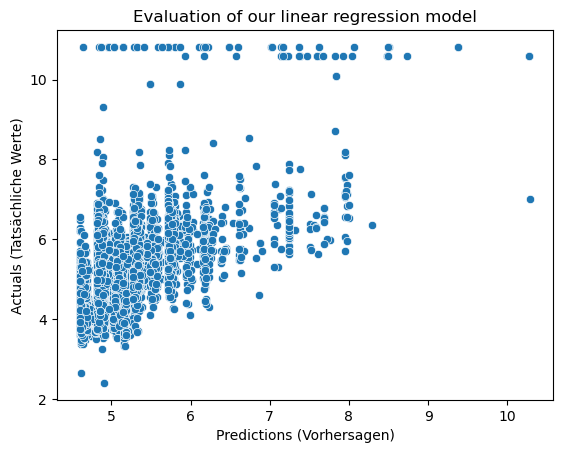

In [106]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions (Vorhersagen)")
plt.ylabel("Actuals (Tatsächliche Werte)")
plt.title("Evaluation of our linear regression model")
plt.show()

In [107]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [109]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  0.5887680738280746
Mean Squared Error:  0.6780967502446339
RMSE:  0.8234663018269988


## Ent-Transformation (wichtiger Schritt)

Um die Modellgüte korrekt zu interpretieren, müssen die Fehlerwerte aus dem logarithmierten Raum zurück in die ursprüngliche Einheit **USD** transformiert werden.

Da im Modell die natürliche Logarithmusfunktion verwendet wurde,

$$
\[
y_{\text{log}} = \ln(y),
\]
$$
erfolgt die Rücktransformation mit der **Exponentialfunktion**:
$$
\[
y = e^{y_{\text{log}}}
\]
$$
---

## Schätzung des mittleren absoluten Fehlers (MAE in USD)

Der mittlere absolute Fehler im Log-Raum (\(\text{MAE}_{\text{log}}\)) lässt sich näherungsweise in den ursprünglichen Raum transformieren durch:

$$
\[
\text{MAE}_{\text{USD}} \approx e^{\text{MAE}_{\text{log}}} - 1
\]
$$

Setzt man den geschätzten Wert ein:

$$
\[
\text{MAE}_{\text{USD}} \approx e^{0.59} - 1
\]
$$

$$
\[
\text{MAE}_{\text{USD}} \approx 1.80 - 1 = 0.80
\]
$$
---

## Interpretation

Das bedeutet, dass das Modell im Durchschnitt einen **relativen Fehler von etwa 80 %** aufweist.

### Beispiel

Angenommen, der wahre Preis beträgt:

\[
y = 100 \ \text{USD}
\]

Dann liegt die Modellvorhersage im Mittel in folgendem Bereich:

\[
100 \cdot (1 - 0.80) \le \hat{y} \le 100 \cdot (1 + 0.80)
\]

\[
20 \ \text{USD} \le \hat{y} \le 180 \ \text{USD}
\]

⚠️ Diese Interpretation ist **vereinfachend**, aber notwendig, um die praktische Modellgüte im ursprünglichen Maßstab zu beurteilen.


<Axes: ylabel='ln_price'>

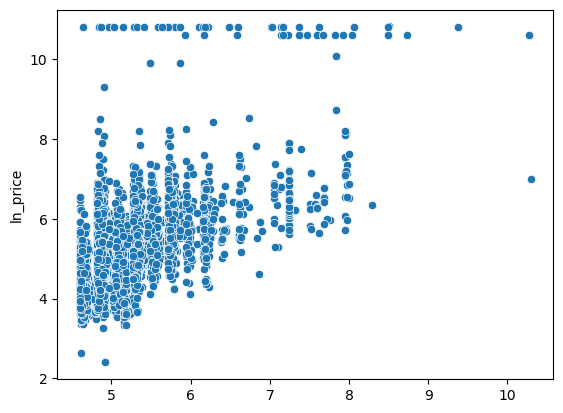

In [110]:
sns.scatterplot(x=predictions, y=y_test)

### Residuals

In [112]:
residuals = y_test - predictions
residuals

23807   -0.098809
20843    0.005002
23495   -0.159613
18970    0.498416
5481    -0.051540
           ...   
26911   -0.650320
13540   -0.502175
20965    0.525714
16030    0.773371
29538    3.432312
Name: ln_price, Length: 6399, dtype: float64

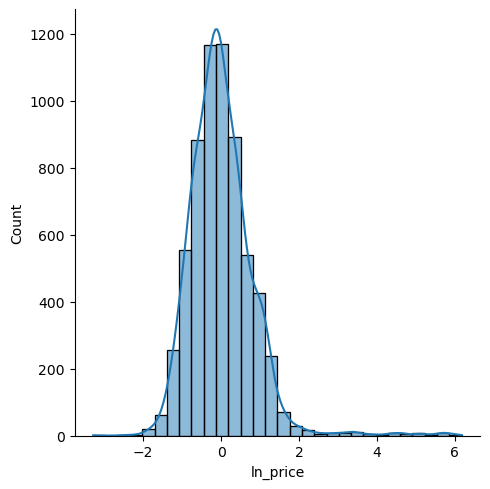

In [117]:
sns.displot(residuals, bins=30, kde=True)

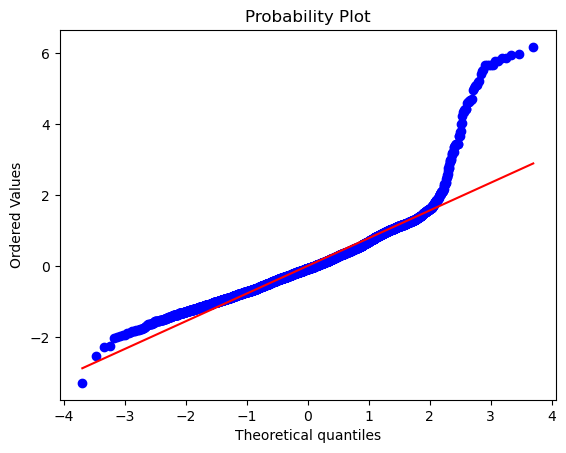

In [121]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()